In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score
from collections import Counter
from rdkit.Chem import AllChem, DataStructs
from rdkit import Chem
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import os
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from rdkit.Chem import Draw
from IPython.display import display
from sklearn.manifold import TSNE
import umap

In [2]:
def smiles_to_morgan_fp(smiles: str, n_bits: int = 1024, radius: int = 2) -> np.ndarray:
    """
    Converts a SMILES string to a Morgan fingerprint.
    """
    mol = Chem.MolFromSmiles(smiles)    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

def show_random_molecules(smiles_list, N=5):
    """
    Given a list of smiles, returns N visualizations of molecules
    """
    sampled_smiles = random.sample(smiles_list, min(N, len(smiles_list)))
    mols = [Chem.MolFromSmiles(smi) for smi in sampled_smiles]
    img = Draw.MolsToGridImage(mols, molsPerRow=10, subImgSize=(200, 200), legends=sampled_smiles)
    display(img)

**REAL NEGATIVES**

In [3]:
df = pd.read_csv("/home/acomajuncosa/Downloads/activities_CHEMBL1794345.tsv", sep='\t', low_memory=False)
df = df[~df['Smiles'].isna()]
print("No pvalues: " + str([i for i in df['pChEMBL Value'].tolist() if not np.isnan(i)]))
print("All are nM: " + str(set([i for i in df['Standard Units']])))

# Generate pChEMBLs
df['pChEMBL_calculated'] = [-np.log10(i * 1e-09) for i in df['Standard Value']]

# Get actives and inactives
actives = df[df['pChEMBL_calculated'] >= 7]['Smiles'].tolist()
inactives = df[df['pChEMBL_calculated'] < 7]['Smiles'].tolist()
print("Actives: " + str(len(actives)))
print("Inactives: " + str(len(inactives)))

# Fix random seed
np.random.seed(42)

# Choose N actives and 1 * N inactives
N = 7000
selected_actives = np.random.choice(actives, N, replace=False).tolist()
selected_inactives = np.random.choice(inactives, 1 * N, replace=False).tolist()
print("Actives: " + str(len(selected_actives)))
print("Inactives: " + str(len(selected_inactives)))

# Get ECFPs
print("Calculating ECFPs...")
actives_smiles = list(selected_actives)
inactives_smiles = list(selected_inactives)
selected_actives = [smiles_to_morgan_fp(i) for i in selected_actives]
selected_inactives = [smiles_to_morgan_fp(i) for i in selected_inactives]

# Create matrices
X = np.array(selected_actives + selected_inactives)
Y = np.array([1]*len(selected_actives) + [0]*len(selected_inactives))
print("Matrix shapes:")
print(X.shape, Y.shape)

No pvalues: []
All are nM: {'nM'}
Actives: 7364
Inactives: 162948
Actives: 7000
Inactives: 7000
Calculating ECFPs...
Matrix shapes:
(14000, 1024) (14000,)


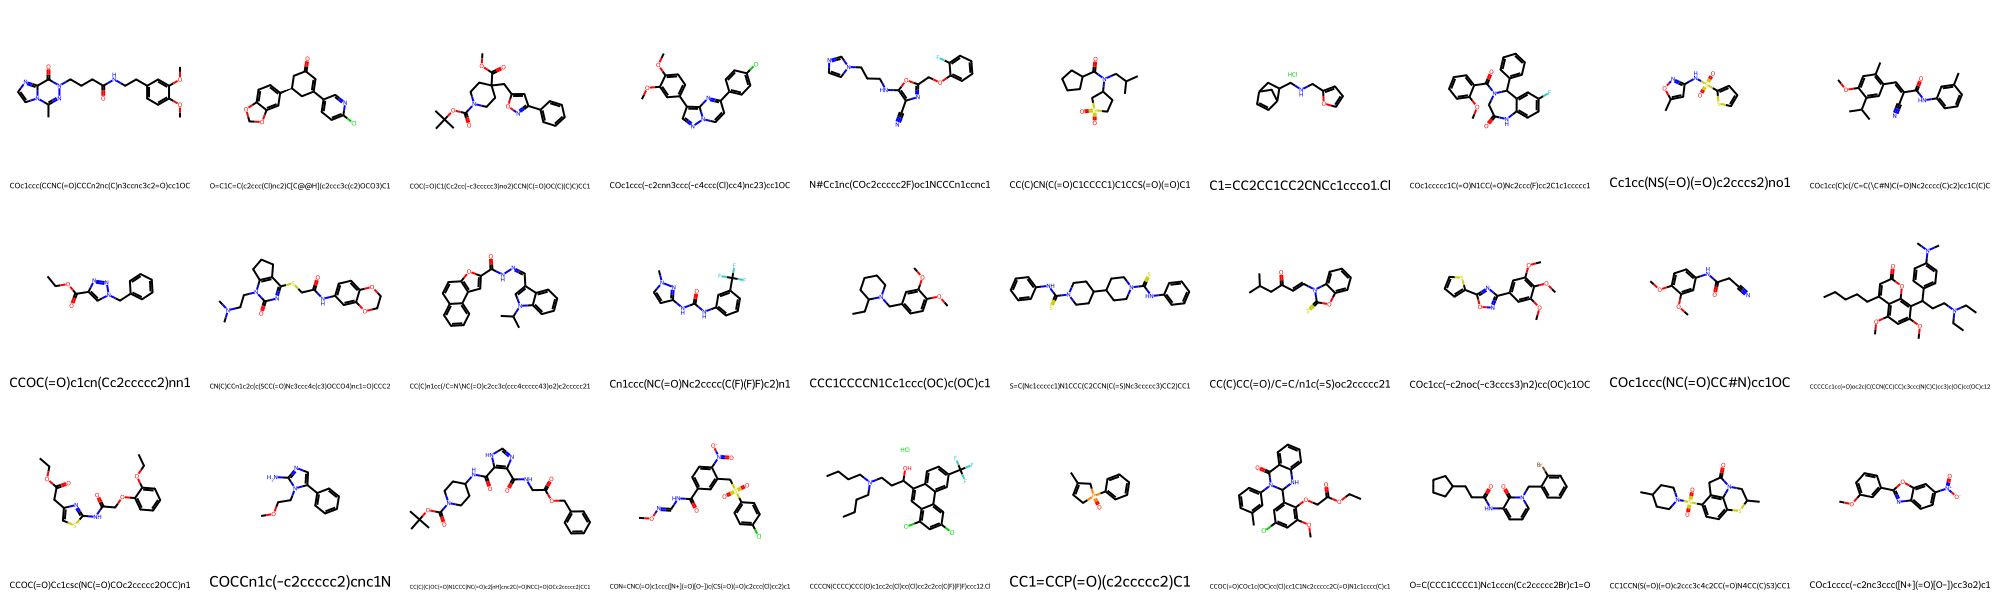

In [4]:
show_random_molecules(actives_smiles, 30)

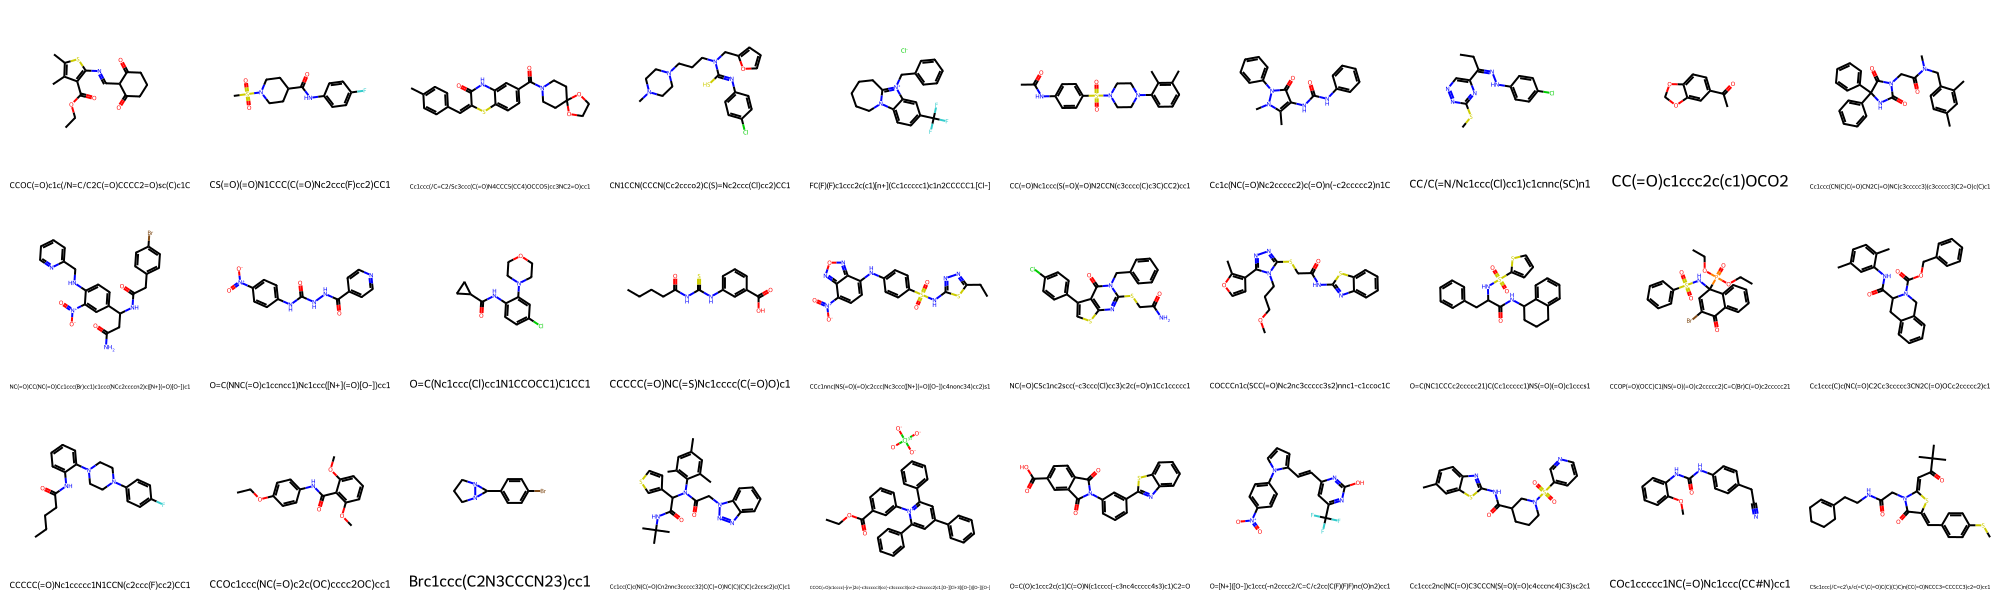

In [5]:
show_random_molecules(inactives_smiles, 30)

In [6]:
ind_act = np.where(Y == 1)[0]
ind_inact = np.where(Y == 0)[0]

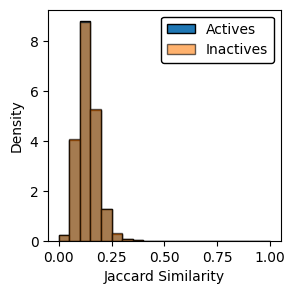

In [7]:
### DISTANCES ###

np.random.seed(42)
X_act_sample = X[ind_act][np.random.choice(len(ind_act), 1500, replace=False)].astype(bool)
X_inact_sample = X[ind_inact][np.random.choice(len(ind_inact), 1500, replace=False)].astype(bool)

dist_act = pairwise_distances(X_act_sample, metric='jaccard')[np.triu_indices(len(X_act_sample), k=1)]
dist_inact = pairwise_distances(X_act_sample, X_inact_sample, metric='jaccard').ravel()

dist_act = dist_act[np.random.choice(len(dist_act), 25000, replace=False)]
dist_inact = dist_inact[np.random.choice(len(dist_inact), 25000, replace=False)]

sim_act = 1 - dist_act
sim_inact = 1 - dist_inact

bins = [i for i in np.arange(0, 1.01, 0.05)]
plt.figure(figsize=(3, 3))
plt.xlabel("Jaccard Similarity")
plt.ylabel("Density")
plt.hist(sim_act, edgecolor='k', bins=bins, label='Actives', density=True)
plt.hist(sim_inact, edgecolor='k', bins=bins, label='Inactives', alpha=0.6, density=True)
plt.legend(loc='upper right', edgecolor='k', framealpha=1)
plt.show()

In [8]:
# Reduce to 2D - umap
reducer = umap.UMAP()
embedding_umap = reducer.fit_transform(X)

# Reduce to 2D - tSNE
tsne = TSNE(n_components=2, random_state=42, n_jobs=8)
embedding_tsne = tsne.fit_transform(X)


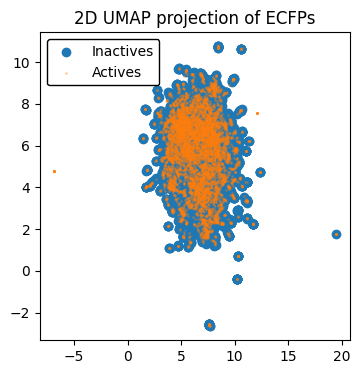

In [9]:
# Plot
plt.figure(figsize=(4,4))
plt.scatter(embedding_umap[ind_inact][:,0], embedding_umap[ind_inact][:,1], label='Inactives')
plt.scatter(embedding_umap[ind_act][:,0], embedding_umap[ind_act][:,1], alpha=0.3, label='Actives', s=1)
plt.legend(loc='upper left', framealpha=1, edgecolor='k')
plt.title("2D UMAP projection of ECFPs")
plt.show()

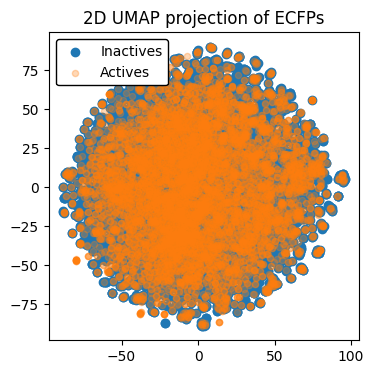

In [11]:
# Plot
plt.figure(figsize=(4,4))
plt.scatter(embedding_tsne[ind_inact][:,0], embedding_tsne[ind_inact][:,1], label='Inactives')
plt.scatter(embedding_tsne[ind_act][:,0], embedding_tsne[ind_act][:,1], alpha=0.3, label='Actives', s=20)
plt.legend(loc='upper left', framealpha=1, edgecolor='k')
plt.title("2D UMAP projection of ECFPs")
plt.show()

In [13]:
# Split into training and test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=24, stratify=Y)

In [17]:
# Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=3, random_state=24, n_jobs=16)
clf.fit(X_train, Y_train)
random.seed(42)
Y_train_shuffled = np.copy(Y_train)
random.shuffle(Y_train_shuffled)
print(f"AUROC TRAIN: {metrics.roc_auc_score(Y_train, clf.predict_proba(X_train)[:,1])}")
print(f"AUROC TRAIN SHUFFLED: {metrics.roc_auc_score(Y_train_shuffled, clf.predict_proba(X_train)[:,1])}")
print(f"AUROC TEST: {metrics.roc_auc_score(Y_test, clf.predict_proba(X_test)[:,1])}")

AUROC TRAIN: 0.9548011160714285
AUROC TRAIN SHUFFLED: 0.4928522640306122
AUROC TEST: 0.5015364795918367


**ChEMBL compounds - random**

In [52]:
df = pd.read_csv("/home/acomajuncosa/Downloads/activities_CHEMBL1794345.tsv", sep='\t', low_memory=False)
df = df[~df['Smiles'].isna()]
print("No pvalues: " + str([i for i in df['pChEMBL Value'].tolist() if not np.isnan(i)]))
print("All are nM: " + str(set([i for i in df['Standard Units']])))

# Generate pChEMBLs
df['pChEMBL_calculated'] = [-np.log10(i * 1e-09) for i in df['Standard Value']]

# Get actives and inactives
actives = df[df['pChEMBL_calculated'] >= 7]['Smiles'].tolist()
inactives = pd.read_csv("/home/acomajuncosa/Downloads/chembl_compounds.tsv", sep='\t', low_memory=False)
inactives = inactives[(~inactives['Smiles'].isna()) & (inactives['Type'] == 'Small molecule')]['Smiles'].tolist()
print("Actives: " + str(len(actives)))
print("Inactives: " + str(len(inactives)))

# Fix random seed
np.random.seed(42)

# Choose N actives and 1 * N inactives
N = 7000
selected_actives = np.random.choice(actives, N, replace=False).tolist()
selected_inactives = np.random.choice(inactives, 1 * N, replace=False).tolist()
print("Actives: " + str(len(selected_actives)))
print("Inactives: " + str(len(selected_inactives)))

# Get ECFPs
print("Calculating ECFPs...")
actives_smiles = list(selected_actives)
inactives_smiles = list(selected_inactives)
selected_actives = [smiles_to_morgan_fp(i) for i in selected_actives]
selected_inactives = [smiles_to_morgan_fp(i) for i in selected_inactives]

# Create matrices
X = np.array(selected_actives + selected_inactives)
Y = np.array([1]*len(selected_actives) + [0]*len(selected_inactives))
print("Matrix shapes:")
print(X.shape, Y.shape)

No pvalues: []
All are nM: {'nM'}
Actives: 7364
Inactives: 1915466
Actives: 7000
Inactives: 7000
Calculating ECFPs...
Matrix shapes:
(14000, 1024) (14000,)


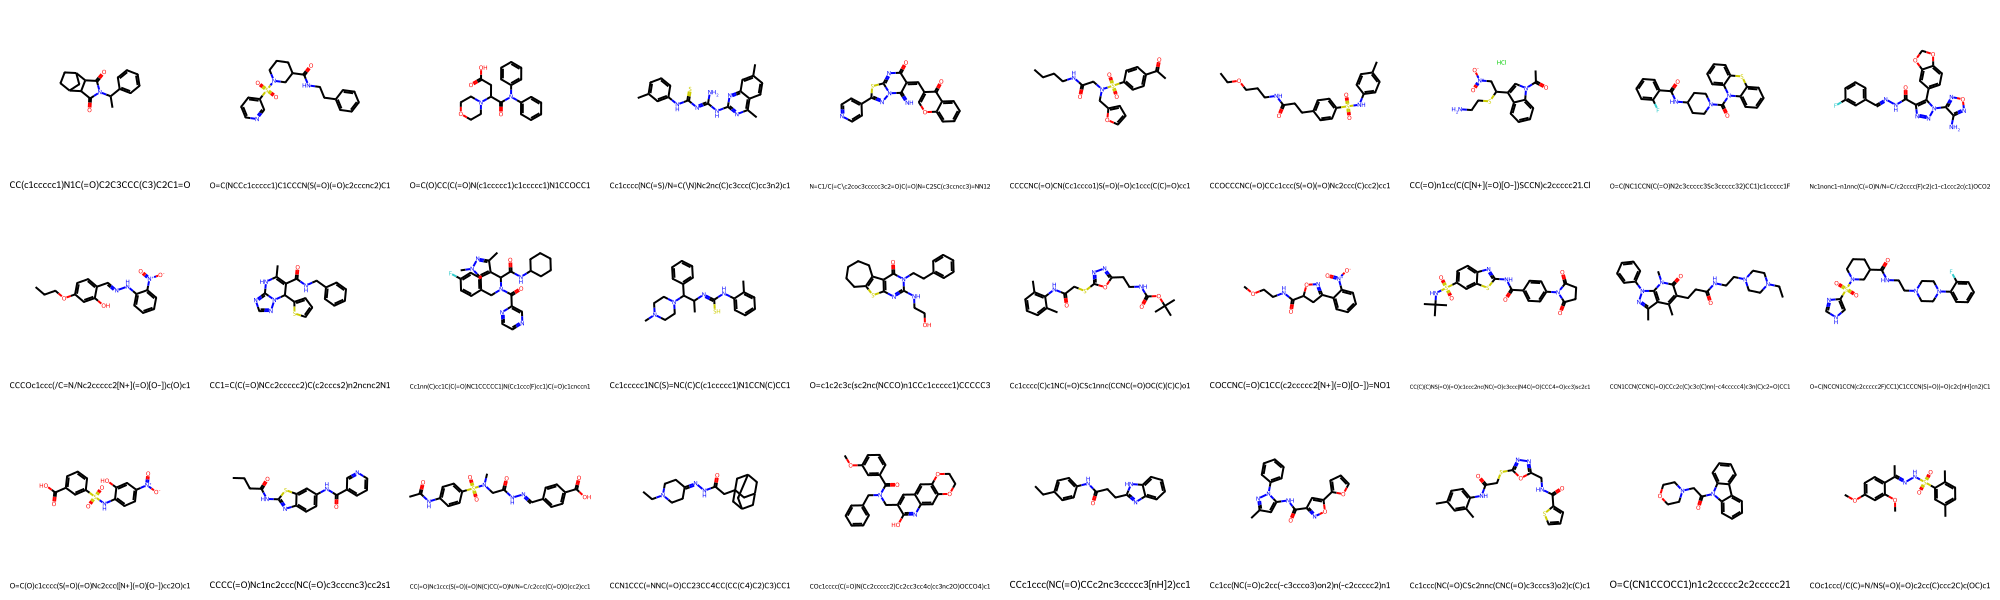

In [53]:
show_random_molecules(actives_smiles, 30)

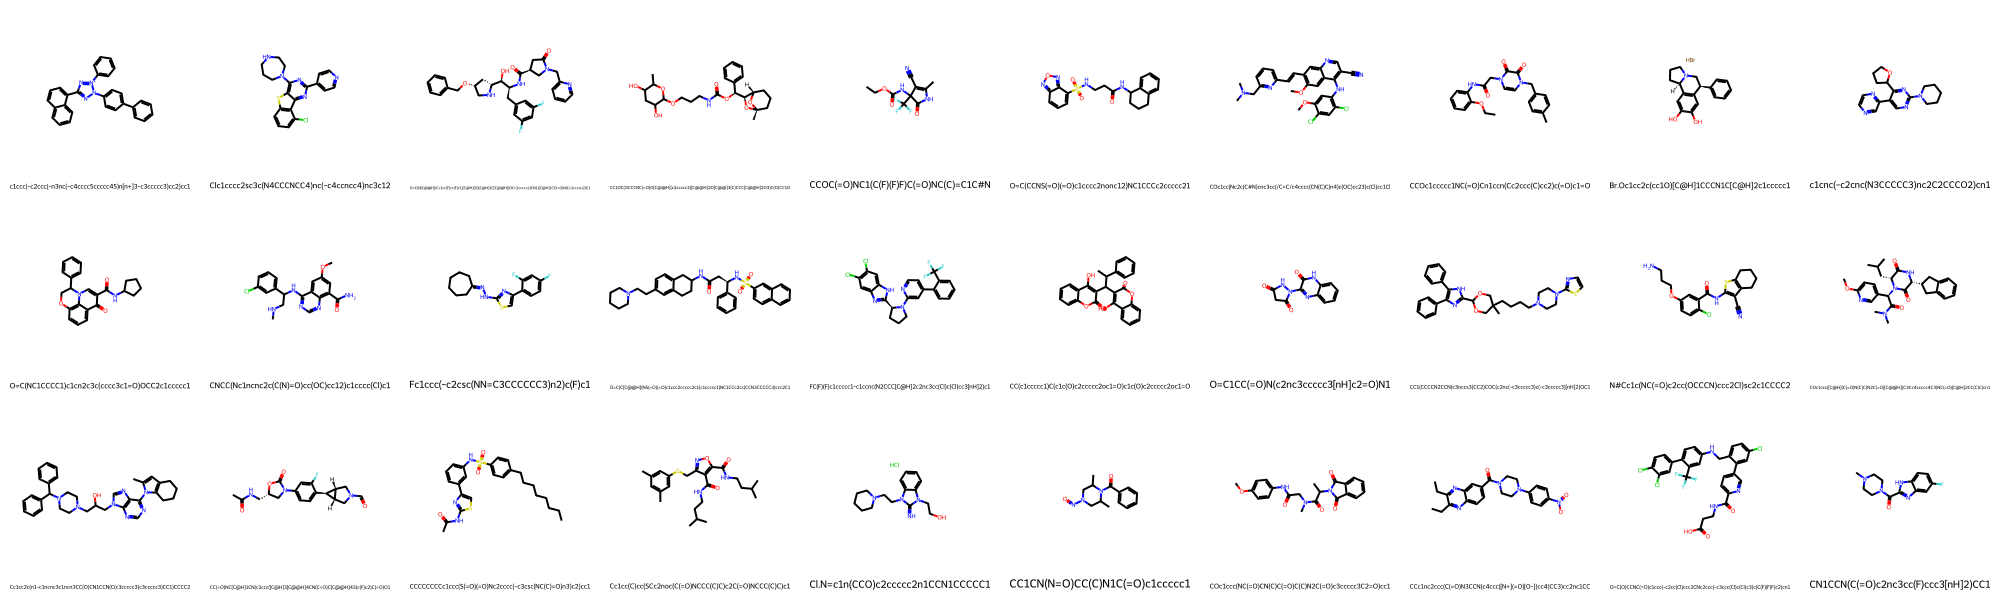

In [54]:
show_random_molecules(inactives_smiles, 30)

In [55]:
ind_act = np.where(Y == 1)[0]
ind_inact = np.where(Y == 0)[0]

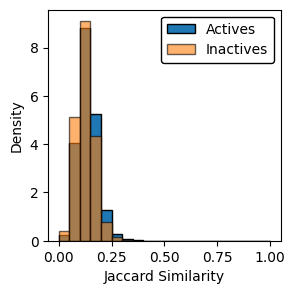

In [56]:
### DISTANCES ###

np.random.seed(42)
X_act_sample = X[ind_act][np.random.choice(len(ind_act), 1500, replace=False)].astype(bool)
X_inact_sample = X[ind_inact][np.random.choice(len(ind_inact), 1500, replace=False)].astype(bool)

dist_act = pairwise_distances(X_act_sample, metric='jaccard')[np.triu_indices(len(X_act_sample), k=1)]
dist_inact = pairwise_distances(X_act_sample, X_inact_sample, metric='jaccard').ravel()

dist_act = dist_act[np.random.choice(len(dist_act), 25000, replace=False)]
dist_inact = dist_inact[np.random.choice(len(dist_inact), 25000, replace=False)]

sim_act = 1 - dist_act
sim_inact = 1 - dist_inact

bins = [i for i in np.arange(0, 1.01, 0.05)]
plt.figure(figsize=(3, 3))
plt.xlabel("Jaccard Similarity")
plt.ylabel("Density")
plt.hist(sim_act, edgecolor='k', bins=bins, label='Actives', density=True)
plt.hist(sim_inact, edgecolor='k', bins=bins, label='Inactives', alpha=0.6, density=True)
plt.legend(loc='upper right', edgecolor='k', framealpha=1)
plt.show()

In [57]:
# Reduce to 2D - umap
reducer = umap.UMAP()
embedding_umap = reducer.fit_transform(X)

# Reduce to 2D - tSNE
tsne = TSNE(n_components=2, random_state=42, n_jobs=8)
embedding_tsne = tsne.fit_transform(X)


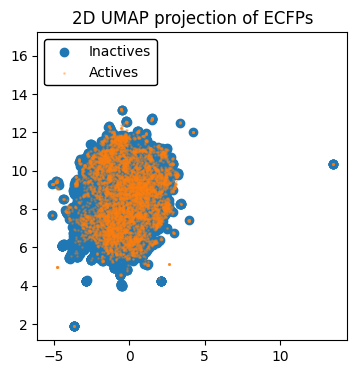

In [58]:
# Plot
plt.figure(figsize=(4,4))
plt.scatter(embedding_umap[ind_inact][:,0], embedding_umap[ind_inact][:,1], label='Inactives')
plt.scatter(embedding_umap[ind_act][:,0], embedding_umap[ind_act][:,1], alpha=0.3, label='Actives', s=1)
plt.legend(loc='upper left', framealpha=1, edgecolor='k')
plt.title("2D UMAP projection of ECFPs")
plt.show()

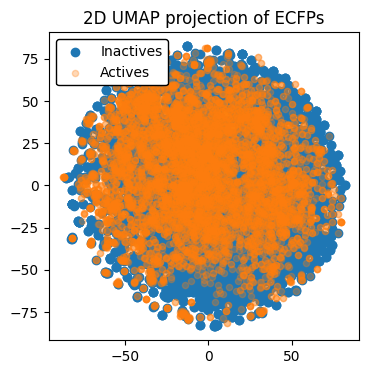

In [59]:
# Plot
plt.figure(figsize=(4,4))
plt.scatter(embedding_tsne[ind_inact][:,0], embedding_tsne[ind_inact][:,1], label='Inactives')
plt.scatter(embedding_tsne[ind_act][:,0], embedding_tsne[ind_act][:,1], alpha=0.3, label='Actives', s=20)
plt.legend(loc='upper left', framealpha=1, edgecolor='k')
plt.title("2D UMAP projection of ECFPs")
plt.show()

In [60]:
# Split into training and test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=24, stratify=Y)

In [62]:
# Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=10, random_state=24, n_jobs=16)
clf.fit(X_train, Y_train)
random.seed(42)
Y_train_shuffled = np.copy(Y_train)
random.shuffle(Y_train_shuffled)
print(f"AUROC TRAIN: {metrics.roc_auc_score(Y_train, clf.predict_proba(X_train)[:,1])}")
print(f"AUROC TRAIN SHUFFLED: {metrics.roc_auc_score(Y_train_shuffled, clf.predict_proba(X_train)[:,1])}")
print(f"AUROC TEST: {metrics.roc_auc_score(Y_test, clf.predict_proba(X_test)[:,1])}")

AUROC TRAIN: 0.9991759885204081
AUROC TRAIN SHUFFLED: 0.48793565051020404
AUROC TEST: 0.734430612244898
